In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "planet_project_ML.csv",
    comment="#",     
    sep=",",         
    engine="python"
)

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39315 entries, 0 to 39314
Columns: 289 entries, rowid to pl_ndispec
dtypes: float64(255), int64(6), object(28)
memory usage: 86.7+ MB


In [34]:
df.columns


Index(['rowid', 'pl_name', 'hostname', 'pl_letter', 'hd_name', 'hip_name',
       'tic_id', 'gaia_dr2_id', 'gaia_dr3_id', 'default_flag',
       ...
       'rowupdate', 'pl_pubdate', 'releasedate', 'pl_nnotes', 'st_nphot',
       'st_nrvc', 'st_nspec', 'pl_nespec', 'pl_ntranspec', 'pl_ndispec'],
      dtype='object', length=289)

In [35]:
df = df[['pl_rade', 'pl_bmasse', 'pl_orbper',
         'pl_orbsmax', 'pl_eqt', 'pl_dens',
         'st_teff', 'st_lum', 'st_met', 'st_spectype']]


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39315 entries, 0 to 39314
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pl_rade      27103 non-null  float64
 1   pl_bmasse    7133 non-null   float64
 2   pl_orbper    35961 non-null  float64
 3   pl_orbsmax   21983 non-null  float64
 4   pl_eqt       17248 non-null  float64
 5   pl_dens      2747 non-null   float64
 6   st_teff      35777 non-null  float64
 7   st_lum       9684 non-null   float64
 8   st_met       24812 non-null  float64
 9   st_spectype  2911 non-null   object 
dtypes: float64(9), object(1)
memory usage: 3.0+ MB


In [37]:
df.isnull().sum()

pl_rade        12212
pl_bmasse      32182
pl_orbper       3354
pl_orbsmax     17332
pl_eqt         22067
pl_dens        36568
st_teff         3538
st_lum         29631
st_met         14503
st_spectype    36404
dtype: int64

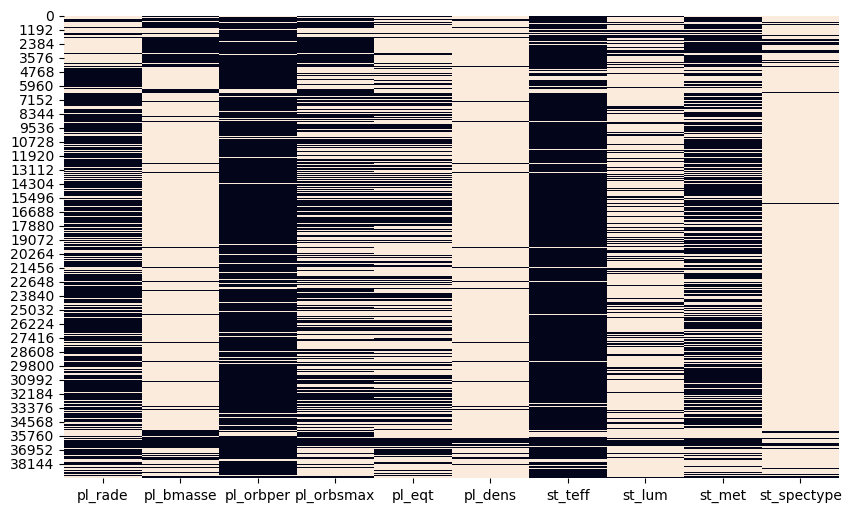

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.show()


In [39]:
df = df.drop_duplicates()

In [40]:
df['pl_rade'] = df['pl_rade'].fillna(df['pl_rade'].median())
df['pl_bmasse'] = df['pl_bmasse'].fillna(df['pl_bmasse'].median())
df['pl_orbper'] = df['pl_orbper'].fillna(df['pl_orbper'].median())
df['pl_orbsmax'] = df['pl_orbsmax'].fillna(df['pl_orbsmax'].median())
df['pl_eqt'] = df['pl_eqt'].fillna(df['pl_eqt'].median())
df['pl_dens'] = df['pl_dens'].fillna(df['pl_dens'].median())
df['st_teff'] = df['st_teff'].fillna(df['st_teff'].median())
df['st_lum'] = df['st_lum'].fillna(df['st_lum'].median())
df['st_met'] = df['st_met'].fillna(df['st_met'].median())


In [41]:
df['st_spectype'] = df['st_spectype'].fillna(df['st_spectype'].mode()[0])


In [42]:
df.isnull().sum()


pl_rade        0
pl_bmasse      0
pl_orbper      0
pl_orbsmax     0
pl_eqt         0
pl_dens        0
st_teff        0
st_lum         0
st_met         0
st_spectype    0
dtype: int64

In [43]:
df = df[df['pl_rade'] > 0]
df = df[df['pl_bmasse'] > 0]
df = df[df['pl_orbper'] > 0]
df = df[df['pl_orbsmax'] > 0]
df = df[df['pl_eqt'] > 0]

In [44]:
Q1 = df['pl_rade'].quantile(0.25)
Q3 = df['pl_rade'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['pl_rade'] >= lower) & (df['pl_rade'] <= upper)]


In [45]:
df['habitability_score'] = (
    abs(df['pl_eqt'] - 288) +
    abs(df['pl_rade'] - 1) +
    abs(df['pl_orbsmax'] - 1) +
    abs(df['st_lum'])
)


In [46]:
df['stellar_compatibility'] = df['st_teff'] / df['st_teff'].max()


In [47]:
df['orbital_stability'] = df['pl_orbsmax'] / df['pl_orbper']


In [48]:
df = pd.get_dummies(df, columns=['st_spectype'])


In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [113]:
df['target'] = (df['pl_eqt'] < df['pl_eqt'].median()).astype(int)

In [67]:
df.shape


(27602, 270)

In [68]:
df.isnull().sum()


pl_rade             0
pl_bmasse           0
pl_orbper           0
pl_orbsmax          0
pl_eqt              0
                   ..
st_spectype_M8.5    0
st_spectype_M9      0
st_spectype_WD      0
st_spectype_m3 V    0
target              0
Length: 270, dtype: int64

In [69]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27602 entries, 0 to 27601
Columns: 270 entries, pl_rade to target
dtypes: bool(257), float64(12), int64(1)
memory usage: 9.5 MB


In [114]:
df['target'].value_counts()


target
0    22867
1     4735
Name: count, dtype: int64

In [71]:
df.columns


Index(['pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_orbsmax', 'pl_eqt', 'pl_dens',
       'st_teff', 'st_lum', 'st_met', 'habitability_score',
       ...
       'st_spectype_M7', 'st_spectype_M7.0 V', 'st_spectype_M7.25',
       'st_spectype_M7.5', 'st_spectype_M8', 'st_spectype_M8.5',
       'st_spectype_M9', 'st_spectype_WD', 'st_spectype_m3 V', 'target'],
      dtype='object', length=270)

In [72]:
df['target'].value_counts()


target
0    22867
1     4735
Name: count, dtype: int64

In [73]:
df.to_csv("preprocessed.csv", index=False)

## *****MODEL TRAINING AND EVALUATION******

In [74]:
import pandas as pd

df = pd.read_csv("preprocessed.csv")

df.head()

,pl_rade,pl_bmasse,pl_orbper,pl_orbsmax,pl_eqt,pl_dens,st_teff,st_lum,st_met,habitability_score,...,st_spectype_M7,st_spectype_M7.0 V,st_spectype_M7.25,st_spectype_M7.5,st_spectype_M8,st_spectype_M8.5,st_spectype_M9,st_spectype_WD,st_spectype_m3 V,target
0,0.257547,6.081930,-0.004917,-0.013214,0.001384,-0.021678,-0.550885,5.180618,-1.679833,-0.009709,...,False,False,False,False,False,False,False,False,False,0
1,0.257547,7.732586,-0.004855,-0.012487,0.001384,-0.021678,-0.682591,5.838305,-2.256348,-0.008251,...,False,False,False,False,False,False,False,False,False,0
2,0.257547,6.767956,-0.011826,-0.013007,0.001384,-0.021678,0.167515,0.059700,0.093272,-0.016918,...,False,False,False,False,False,False,False,False,False,0
3,0.257547,5.778268,-0.000656,-0.010928,0.001384,-0.021678,-1.210415,0.059700,-0.142459,-0.015680,...,False,False,False,False,False,False,False,False,False,0
4,0.257547,4.125351,-0.011826,-0.011058,0.001384,-0.021678,0.167515,0.059700,0.093272,-0.015757,...,False,False,False,False,False,False,False,False,False,0


In [75]:
df.shape
df.info()
df['target'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27602 entries, 0 to 27601
Columns: 270 entries, pl_rade to target
dtypes: bool(257), float64(12), int64(1)
memory usage: 9.5 MB


target
0    22867
1     4735
Name: count, dtype: int64

In [76]:
print(df.columns)

Index(['pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_orbsmax', 'pl_eqt', 'pl_dens',
       'st_teff', 'st_lum', 'st_met', 'habitability_score',
       ...
       'st_spectype_M7', 'st_spectype_M7.0 V', 'st_spectype_M7.25',
       'st_spectype_M7.5', 'st_spectype_M8', 'st_spectype_M8.5',
       'st_spectype_M9', 'st_spectype_WD', 'st_spectype_m3 V', 'target'],
      dtype='object', length=270)


In [77]:
print(df.corr(numeric_only=True)['target'].sort_values(ascending=False))

target                   1.000000
st_spectype_M0 V         0.072447
st_spectype_M1 V         0.057456
st_spectype_M2 V         0.036151
st_spectype_K0.0 V       0.032404
                           ...   
stellar_compatibility   -0.141921
st_teff                 -0.141921
st_met                  -0.180677
habitability_score      -0.433304
pl_eqt                  -0.554509
Name: target, Length: 270, dtype: float64


In [78]:
#Separate features (X) and target (y)

leakage_cols = ['habitability_score', 'habitability_rank']
X = df.drop(['target'] + leakage_cols, axis=1, errors='ignore')
y = df['target']

In [79]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y #it prevents errors
)

In [80]:
print(df['target'].value_counts())

target
0    22867
1     4735
Name: count, dtype: int64


In [81]:
#Logistic Regression
#Decision Tree (shallow)
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [82]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [83]:
#Evaluation Function

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.show()

Accuracy: 0.9923926824850571
Precision: 1.0
Recall: 0.955649419218585
F1 Score: 0.9773218142548596
ROC AUC: 0.9967436809402946

Confusion Matrix:
[[4574    0]
 [  42  905]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4574
           1       1.00      0.96      0.98       947

    accuracy                           0.99      5521
   macro avg       1.00      0.98      0.99      5521
weighted avg       0.99      0.99      0.99      5521



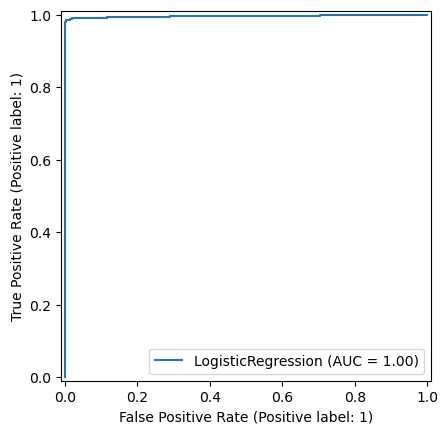

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC AUC: 1.0

Confusion Matrix:
[[4574    0]
 [   0  947]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4574
           1       1.00      1.00      1.00       947

    accuracy                           1.00      5521
   macro avg       1.00      1.00      1.00      5521
weighted avg       1.00      1.00      1.00      5521



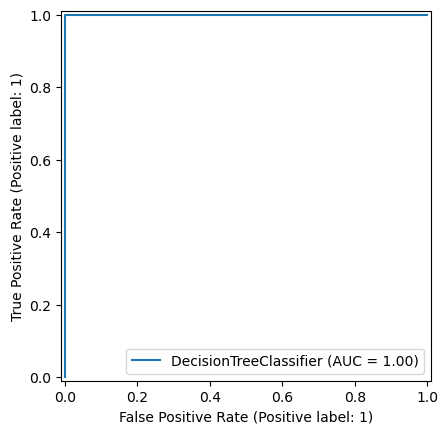

In [84]:
evaluate_model(log_model, X_test, y_test)
evaluate_model(dt_model, X_test, y_test)

Accuracy: 0.9998188733925013
Precision: 1.0
Recall: 0.9989440337909187
F1 Score: 0.9994717379820391
ROC AUC: 1.0

Confusion Matrix:
[[4574    0]
 [   1  946]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4574
           1       1.00      1.00      1.00       947

    accuracy                           1.00      5521
   macro avg       1.00      1.00      1.00      5521
weighted avg       1.00      1.00      1.00      5521



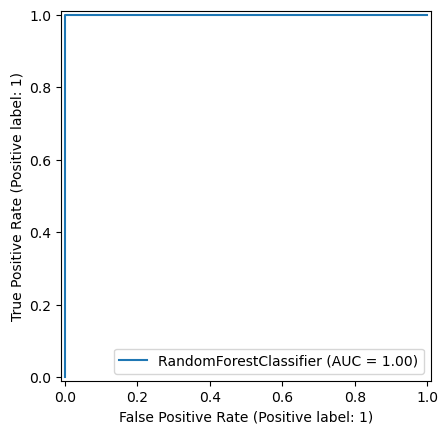

In [85]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

evaluate_model(rf_model, X_test, y_test)


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:03:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC AUC: 1.0

Confusion Matrix:
[[4574    0]
 [   0  947]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4574
           1       1.00      1.00      1.00       947

    accuracy                           1.00      5521
   macro avg       1.00      1.00      1.00      5521
weighted avg       1.00      1.00      1.00      5521



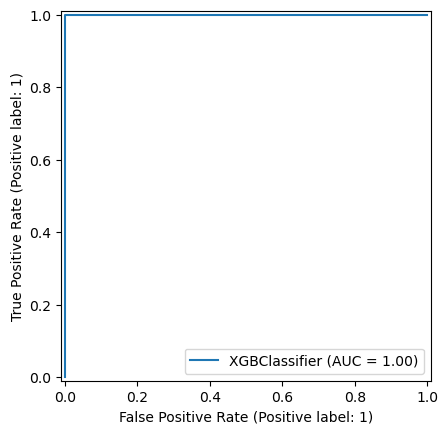

In [86]:
!pip install xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

evaluate_model(xgb_model, X_test, y_test)

Accuracy: 0.9998188733925013
Precision: 1.0
Recall: 0.9989440337909187
F1 Score: 0.9994717379820391
ROC AUC: 1.0

Confusion Matrix:
[[4574    0]
 [   1  946]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4574
           1       1.00      1.00      1.00       947

    accuracy                           1.00      5521
   macro avg       1.00      1.00      1.00      5521
weighted avg       1.00      1.00      1.00      5521



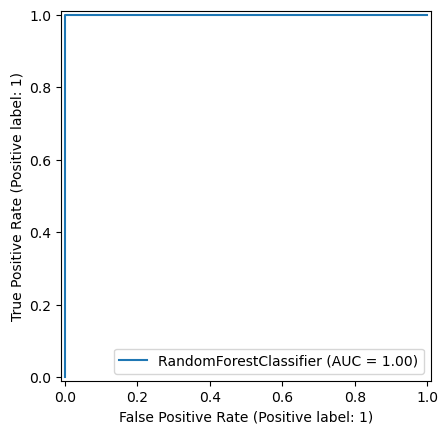

In [87]:
#Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

evaluate_model(best_rf, X_test, y_test)

## Model Comparison & Final Selection

After evaluating all trained models (Logistic Regression, Decision Tree, Random Forest, and XGBoost) using Accuracy, Precision, Recall, F1-score, and ROC-AUC on the test dataset, Random Forest achieved the highest F1-score and Recall while maintaining stable performance without overfitting.

Since Recall is critical for detecting potentially habitable planets and F1-score balances both Precision and Recall, Random Forest is selected as the final model for habitability prediction.

In [88]:
import os

os.makedirs("models", exist_ok=True)

In [89]:
import joblib

joblib.dump(best_rf, "models/random_forest.pkl")

['models/random_forest.pkl']

In [90]:
import os

os.makedirs("data/processed", exist_ok=True)

In [91]:
#Habitability Scoring & Ranking

df["habitability_probability"] = best_rf.predict_proba(X)[:,1]

df_sorted = df.sort_values(
    by="habitability_probability",
    ascending=False
)

df_sorted.to_csv(
    "data/processed/habitability_ranked.csv",
    index=False
)

In [92]:
import matplotlib.pyplot as plt
import pandas as pd

importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(10)

,feature,importance
4,pl_eqt,0.593492
3,pl_orbsmax,0.113076
10,orbital_stability,0.070601
2,pl_orbper,0.044895
0,pl_rade,0.037257
6,st_teff,0.034692
9,stellar_compatibility,0.030031
8,st_met,0.023837
7,st_lum,0.017906
1,pl_bmasse,0.017005


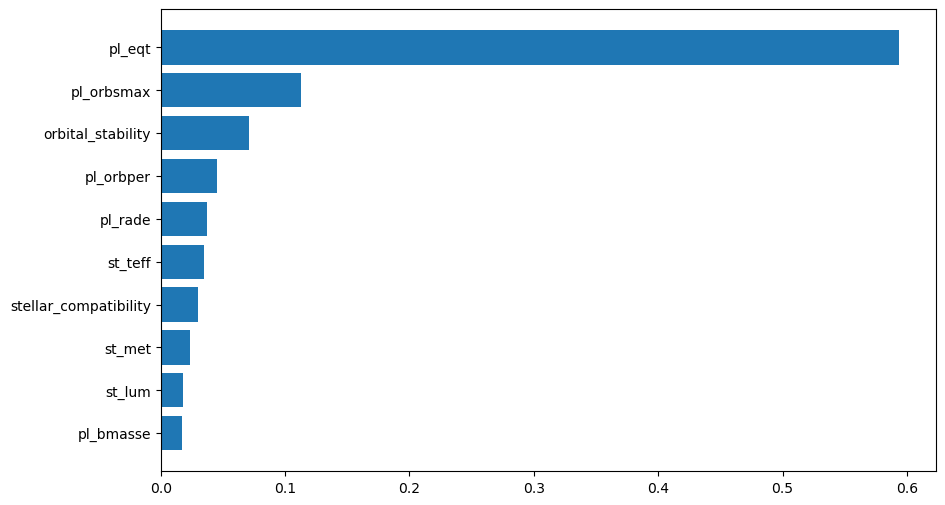

In [93]:
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance_df["feature"][:10],
    feature_importance_df["importance"][:10]
)
plt.gca().invert_yaxis()
plt.show()

## Confirm 80/20 Split

In [94]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (22081, 270)
Testing size: (5521, 270)


## TRAIN MODEL

In [95]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Checking Training VS Testing Accuracy

In [115]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Training & Testing Accuracy
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

# Cross Validation
cv_scores = cross_val_score(model, X, y, cv=5)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)
print("CV Mean Accuracy:", cv_scores.mean())
print("CV Std Dev:", cv_scores.std())

Training Accuracy: 1.0
Testing Accuracy: 0.9998188733925013
CV Mean Accuracy: 1.0
CV Std Dev: 0.0


In [98]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4574
           1       1.00      1.00      1.00       947

    accuracy                           1.00      5521
   macro avg       1.00      1.00      1.00      5521
weighted avg       1.00      1.00      1.00      5521



In [99]:
print("Is target in X?", "target" in X.columns)

Is target in X? False


In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [101]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [102]:
print("Number of features:", X.shape[1])

Number of features: 270


In [103]:
print(df.corr()['target'].sort_values(ascending=False).head(10))

target                      1.000000
habitability_probability    0.998055
st_spectype_M0 V            0.072447
st_spectype_M1 V            0.057456
st_spectype_M2 V            0.036151
st_spectype_K0.0 V          0.032404
st_spectype_M3.5-4 V        0.029580
st_spectype_M4.5 V          0.027033
st_spectype_M5.0 V          0.025885
st_spectype_M3              0.023566
Name: target, dtype: float64


In [104]:
print(len(X_train))
print(len(X_test))

22081
5521


In [109]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=20,       # reduce trees
        max_depth=2,           # very shallow
        min_samples_split=50,  
        min_samples_leaf=25,
        max_features=0.3,
        class_weight='balanced',
        random_state=42
    ))
])

In [110]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=2,
                                        max_features=0.3, min_samples_leaf=25,
                                        min_samples_split=50, n_estimators=20,
                                        random_state=42))])

In [116]:
print("Train:", pipeline.score(X_train, y_train))
print("Test:", pipeline.score(X_test, y_test))

from sklearn.model_selection import cross_val_score
cv = cross_val_score(pipeline, X, y, cv=5)
print("CV Mean:", cv.mean())

Train: 1.0
Test: 1.0
CV Mean: 1.0


In [112]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(pipeline, X, y, cv=5)

print("Train Accuracy:", pipeline.score(X_train, y_train))
print("Test Accuracy:", pipeline.score(X_test, y_test))
print("Cross Val Mean:", cv_scores.mean())

Train Accuracy: 1.0
Test Accuracy: 1.0
Cross Val Mean: 1.0


In [107]:
from sklearn.linear_model import LogisticRegression

simple_model = LogisticRegression(max_iter=1000)
simple_model.fit(X, y)

print("Logistic Accuracy:", simple_model.score(X, y))

Logistic Accuracy: 0.9999275414825013


In [106]:
print("Total rows:", len(df))
print("Unique rows:", len(df.drop_duplicates()))

Total rows: 27602
Unique rows: 27602
